In [155]:
import time
from collections import defaultdict
from typing import Callable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from IPython.display import HTML, clear_output, display
import plotly.graph_objects as go
import statsmodels
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import tsfresh
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

## Обработка

In [156]:
chemicals_raw = pd.read_excel(
    "/home/danilach/mipt-stats/SberTs/Цены удобрения и химия_до 06.2025-1.xlsx"
)

In [157]:
chemicals_raw = pd.read_excel(
    "/home/danilach/mipt-stats/SberTs/Цены удобрения и химия_до 06.2025-1.xlsx"
)

chemicals_raw = chemicals_raw.T
chemicals_raw.set_index(1)
chemicals_raw.columns = chemicals_raw.iloc[0]
chemicals_raw = chemicals_raw[2:]
chemicals_raw.index = pd.to_datetime(chemicals_raw.index)
chemicals_raw.index.name = "Date"
chemicals_raw.columns.name = "chemical"

In [158]:
products = chemicals_raw.dropna(axis="columns")
products.head()

chemical,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай"
Date,,,,,,,,,,
2016-01-01,209.875,366.25,120.0,266.666667,199.375,278.75,1153.0,185.4,556.0,987.5
2016-02-01,207.125,332.5,117.5,260.5,182.125,272.5,1163.0,150.0,546.25,927.5
2016-03-01,199.875,345.0,117.5,267.5,180.3,267.5,1290.0,164.75,625.0,1173.75
2016-04-01,203.875,346.25,115.0,271.0,172.0,267.5,1355.0,179.9,642.0,1192.5
2016-05-01,200.5,341.5,107.5,279.25,154.75,251.875,1278.0,201.25,631.25,1160.0


In [159]:
macro = pd.read_excel("/home/danilach/mipt-stats/SberTs/global_macro.xlsx", index_col="Date")   
macro.head()

,"Инфляция - Рост индекса цен производителей (RUB, eop PPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI), .1","Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),","Ключевая ставка, годовых","Инфляция, г/г"
Date,,,,,,
"08,2025",NaN,0.2,0.2,0.009,NaN,NaN
"07,2025",-0.013,0.3,0.3,0.000,18.0,8.79
"06,2025",-0.013,0.1,0.1,0.001,20.0,9.40
"05,2025",-0.014,0.2,0.2,-0.005,21.0,9.88
"04,2025",-0.015,-0.1,-0.1,-0.004,21.0,10.23


In [160]:
print(len(macro))
print(len(products))
print(products.index[0])
print(products.index[-1])
print(macro.index[0])
print(macro.index[-1])

140
114
2016-01-01 00:00:00
2025-06-01 00:00:00
08,2025
01,2014


In [161]:
macro = macro[::-1]
macro = macro[24:-2]
print(macro.index[0])
print(macro.index[-1])
print(products.index[0])
print(products.index[-1])

01,2016
06,2025
2016-01-01 00:00:00
2025-06-01 00:00:00


In [162]:
df = products.copy()
df[macro.columns] = macro.values

df.head()

chemical,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай","Инфляция - Рост индекса цен производителей (RUB, eop PPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI), .1","Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),","Ключевая ставка, годовых","Инфляция, г/г"
Date,,,,,,,,,,,,,,,,
2016-01-01,209.875,366.25,120.0,266.666667,199.375,278.75,1153.0,185.4,556.0,987.5,-0.022,-0.1,-0.1,-0.002,11.0,9.8
2016-02-01,207.125,332.5,117.5,260.5,182.125,272.5,1163.0,150.0,546.25,927.5,-0.012,0.0,0.0,0.001,11.0,8.1
2016-03-01,199.875,345.0,117.5,267.5,180.3,267.5,1290.0,164.75,625.0,1173.75,-0.015,-0.2,-0.2,-0.002,11.0,7.3
2016-04-01,203.875,346.25,115.0,271.0,172.0,267.5,1355.0,179.9,642.0,1192.5,0.031,0.1,0.1,-0.001,11.0,7.3
2016-05-01,200.5,341.5,107.5,279.25,154.75,251.875,1278.0,201.25,631.25,1160.0,0.026,0.4,0.4,0.002,11.0,7.3


In [163]:
scaler = StandardScaler()

df_normalized = pd.DataFrame(
    scaler.fit_transform(df), columns=df.columns, index=df.index
)

means = scaler.mean_
stds = scaler.scale_

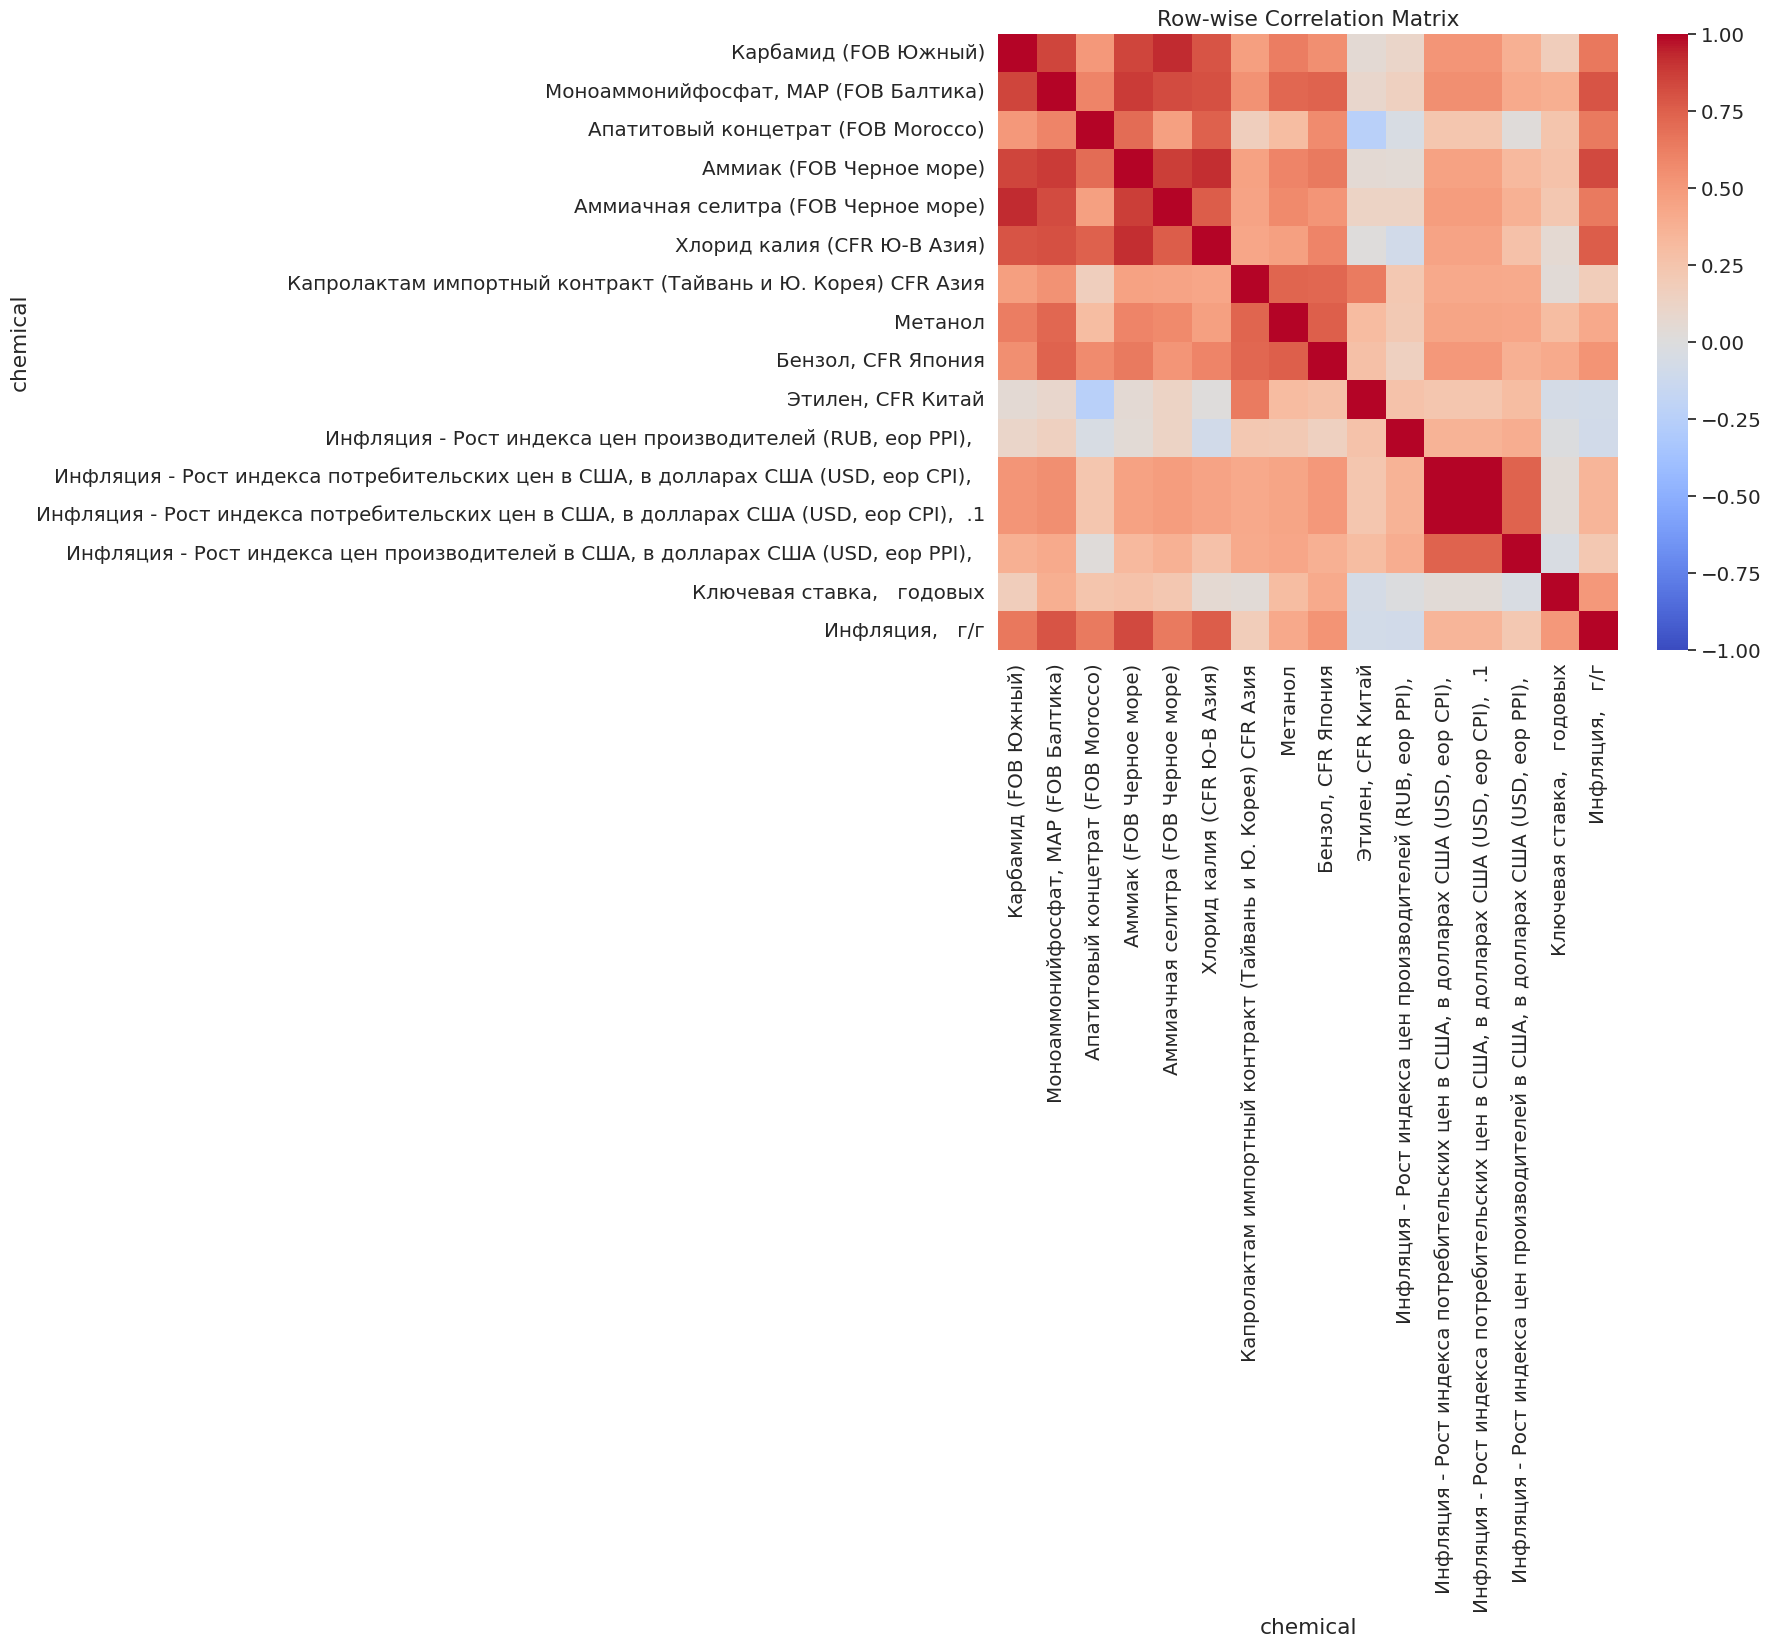

In [164]:
corr_matrix = df_normalized.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Row-wise Correlation Matrix")
plt.show()

## Baseline (single future value)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

class SimpleCorrModel:
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.scaler = StandardScaler()
        
        self.df_normalized = pd.DataFrame(
            self.scaler.fit_transform(self.df), 
            columns=self.df.columns, 
            index=self.df.index
        )
        
        self.means = self.scaler.mean_
        self.stds = self.scaler.scale_
        self.corr_matrix = self.df_normalized.corr()

    def make_prediction(self, index: str, value: float, horizon: int = 12, threshold: float = 0.75):
        """
        index: имя показателя (колонка), для которого пользователь задаёт значение
        value: новое значение этого показателя через horizon
        horizon: сколько шагов вперёд (пока используется как метка, но можно расширить под time series)
        threshold: порог корреляции
        """
        if index not in self.df.columns:
            raise ValueError(f"Индекс {index} отсутствует в данных")
        
        # нормализованное новое значение
        norm_value = (value - self.scaler.mean_[self.df.columns.get_loc(index)]) / self.scaler.scale_[self.df.columns.get_loc(index)]
        
        # корреляции
        correlations = self.corr_matrix[index]
        correlated = correlations[abs(correlations) >= threshold].drop(index)  # убираем сам индекс
        
        predictions = {}
        for col, corr in correlated.items():
            # простая линейная аппроксимация: новое значение = корреляция * norm_value
            pred_norm = corr * norm_value  
            
            # денормализация
            pred_value = pred_norm * self.scaler.scale_[self.df.columns.get_loc(col)] + self.scaler.mean_[self.df.columns.get_loc(col)]
            predictions[col] = pred_value
        
        return predictions


In [186]:
g = SimpleCorrModel(df)

In [188]:
g.make_prediction(df.columns[3], 12)


{'Карбамид (FOB Южный)': 144.0199478083935,
 'Моноаммонийфосфат, MAP (FOB Балтика)': 252.90382378551095,
 'Аммиачная селитра (FOB Черное море)': 86.41470070199452,
 'Хлорид калия (CFR Ю-В Азия)': 131.42084240690562,
 'Инфляция,   г/г': 2.235119195583251}

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def cross_validate_corr_model(
    model_class,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    threshold: float,
    target_col: str
):
    """
    Проводит кросс-валидацию для корреляционной модели.

    model_class: класс модели (например SimpleCorrModel), неинициализированный
    df: DataFrame со всеми показателями
    horizon: горизонт прогнозирования (в шагах)
    stride: шаг кросс-валидации (размер теста на каждом фолде)
    start_window: размер первой обучающей выборки
    threshold: порог корреляции
    target_col: название колонки, значение которой фиксируем
    """

    n = len(df)
    errors = {}  # {col: [ошибки по фолдам]}

    for train_end in range(start_window, n - horizon, stride):
        train_df = df.iloc[:train_end]
        test_start = train_end
        test_end = min(train_end + stride, n - horizon)  # кусок теста
        test_df = df.iloc[test_start:test_end]

        # обучаем модель
        model = model_class(train_df)

        for t in range(len(test_df)):
            idx = test_df.index[t]
            # фактическое значение target через horizon шагов
            true_target = df[target_col].iloc[test_start + t + horizon]

            # делаем прогноз
            preds = model.make_prediction(
                index=target_col,
                value=true_target,
                horizon=horizon,
                threshold=threshold
            )

            # сравниваем предсказания с истинными значениями
            for col, pred_value in preds.items():
                true_value = df[col].iloc[test_start + t + horizon]
                mse = (pred_value - true_value) ** 2

                if col not in errors:
                    errors[col] = []
                errors[col].append(mse)

    # усредняем по фолдам
    mse_results = {col: np.mean(vals) for col, vals in errors.items()}
    return mse_results


In [ ]:
def build_error_matrix(
    model_class,
    df,
    horizon,
    stride,
    start_window,
    threshold,
):
    """
    Строит матрицу ошибок: строки = целевые признаки (index в make_prediction),
    колонки = предсказываемые признаки.
    В ячейке — MAPE (float) или NaN.
    """

    features = df.columns
    error_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

    for i, feat in enumerate(features):
        mape_results, _ = cross_validate_corr_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            threshold=threshold,
            index=i,  # передаем индекс
        )

        # mape_results имеет формат {col: "12.3%"} — нужно преобразовать в float
        for col, val in mape_results.items():
            try:
                num_val = float(val.strip("%"))
            except:
                num_val = np.nan
            error_matrix.loc[feat, col] = num_val

    return error_matrix

In [ ]:
def plot_error_matrix(error_matrix, cmap="RdYlGn_r", figsize=(10, 8)):
    """
    Визуализация матрицы ошибок (например, MAPE).
    error_matrix: pd.DataFrame (строки = входные признаки, колонки = предсказываемые признаки)
    """

    fig, ax = plt.subplots(figsize=figsize)

    # данные в numpy
    data = error_matrix.to_numpy(dtype=float)

    # маска NaN (чтобы серым закрасить)
    mask = np.isnan(data)

    # карта цветов: NaN = серый
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="lightgray")

    im = ax.imshow(data, cmap=cmap_obj, aspect="auto")

    # подписи
    ax.set_xticks(np.arange(len(error_matrix.columns)))
    ax.set_yticks(np.arange(len(error_matrix.index)))
    ax.set_xticklabels(error_matrix.columns, rotation=90)
    ax.set_yticklabels(error_matrix.index)

    # цветовая шкала
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("MAPE (%)")

    # сетка
    ax.set_xticks(np.arange(-0.5, len(error_matrix.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(error_matrix.index), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title("Error Matrix (MAPE %)")
    plt.tight_layout()
    plt.show()

In [ ]:
err_mat_12 = build_error_matrix(
    model_class=SimpleCorrModel,
    df=df,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.7,
)

/tmp/ipykernel_946060/3099831815.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()
/tmp/ipykernel_946060/3099831815.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


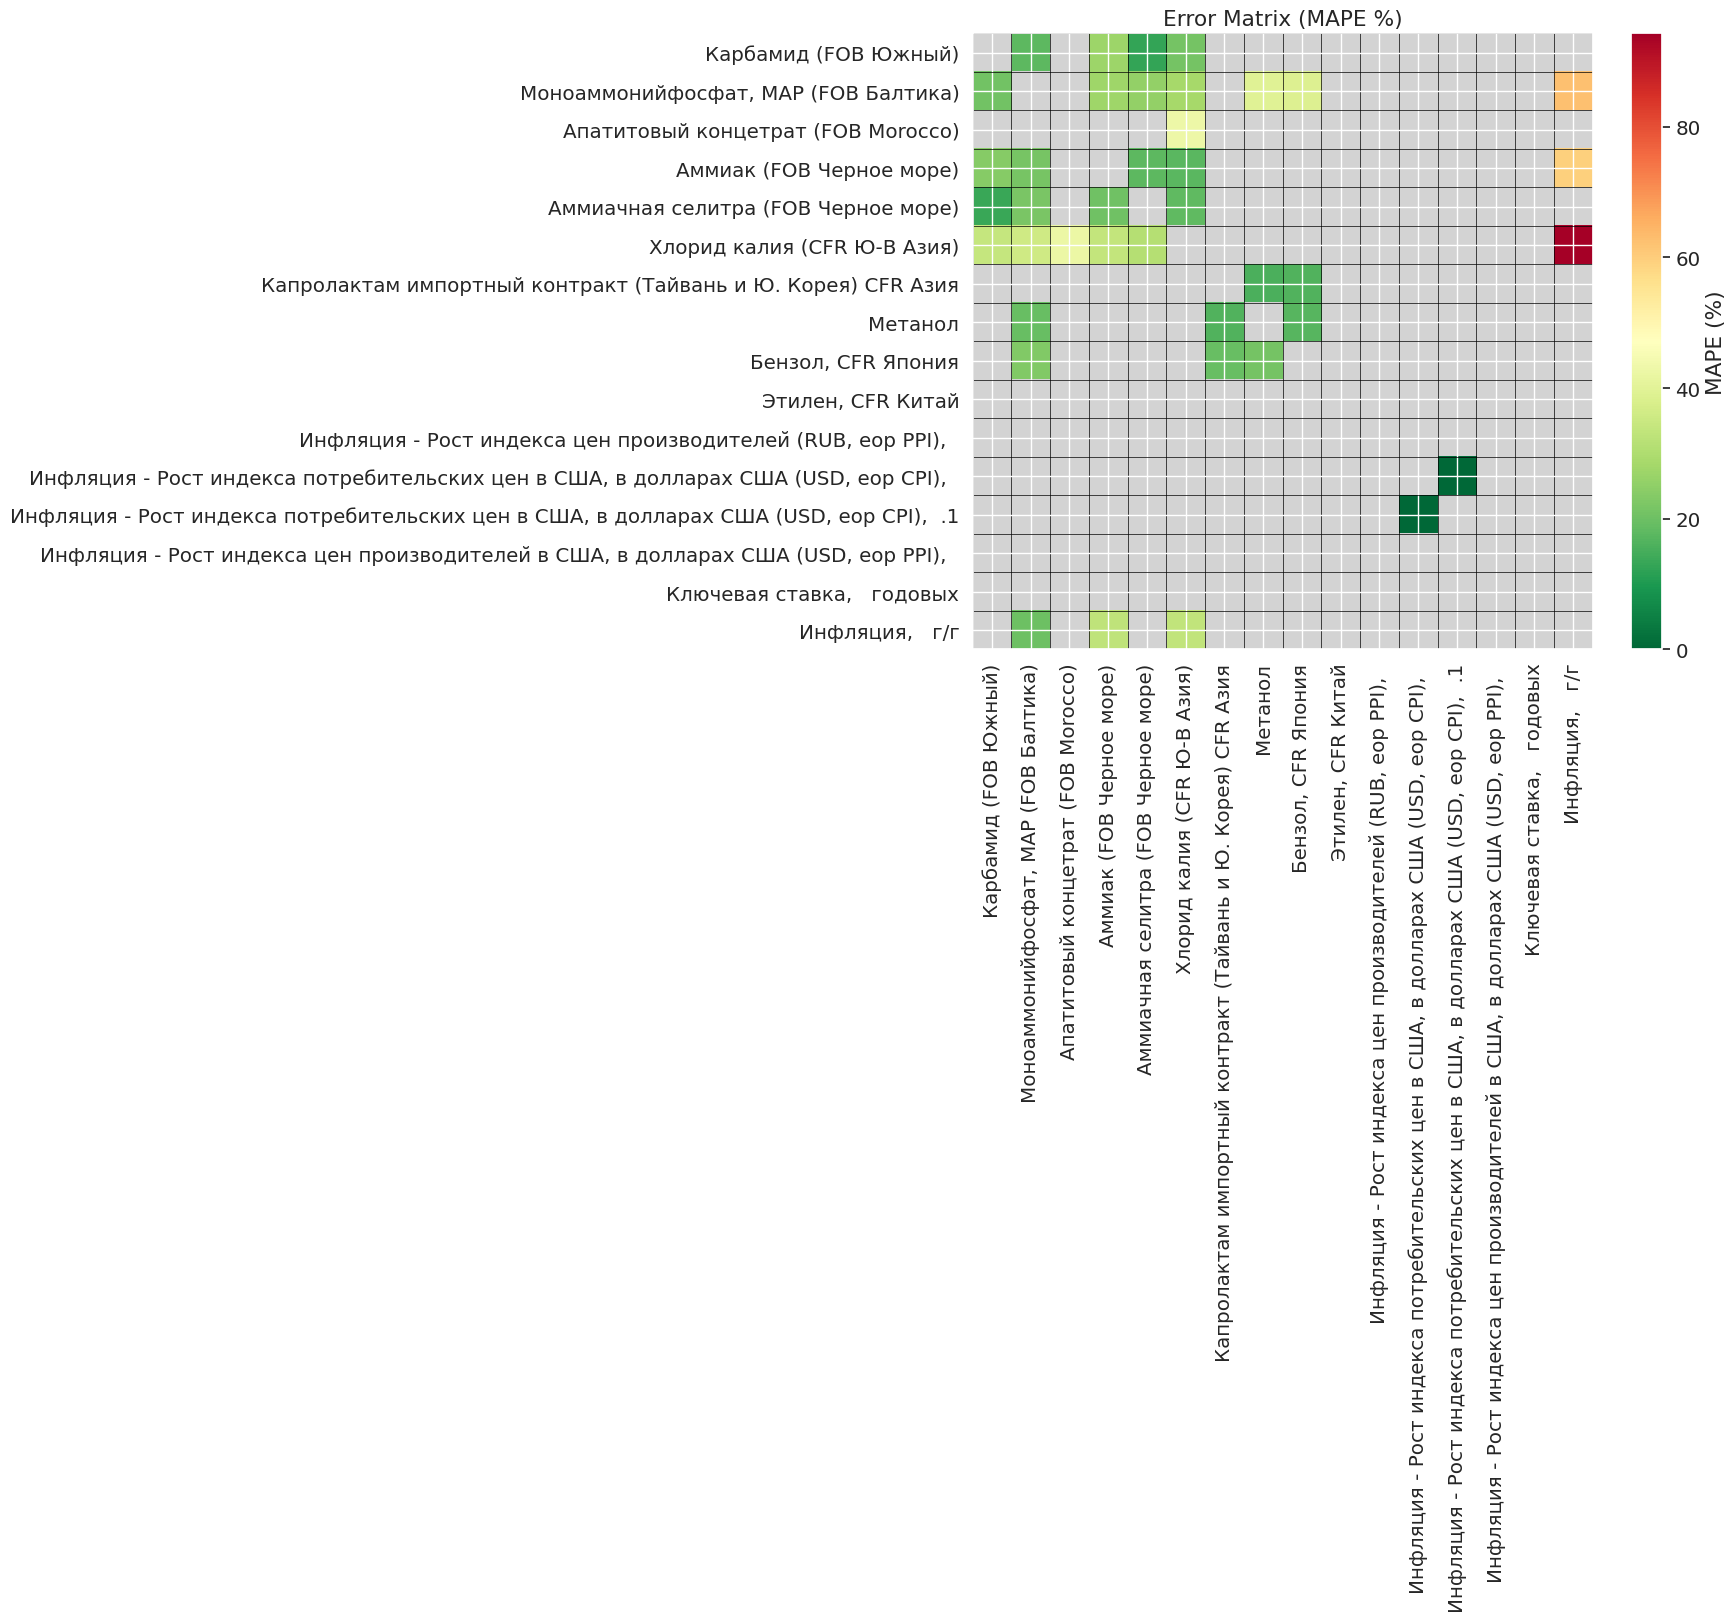

In [ ]:
plot_error_matrix(err_mat_12)

In [ ]:
results = cross_validate_corr_model(
    SimpleCorrModel,
    df=df,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    index=3
)

print(results[1])
print("=" * 155)
print(results[0])

{'Карбамид (FOB Южный)': 78, 'Моноаммонийфосфат, MAP (FOB Балтика)': 78, 'Аммиачная селитра (FOB Черное море)': 78, 'Хлорид калия (CFR Ю-В Азия)': 78, 'Инфляция,   г/г': 78}
{'Карбамид (FOB Южный)': '23.7%', 'Моноаммонийфосфат, MAP (FOB Балтика)': '21.7%', 'Аммиачная селитра (FOB Черное море)': '17.8%', 'Хлорид калия (CFR Ю-В Азия)': '17.5%', 'Инфляция,   г/г': '59.6%'}
